# 03. 하이퍼파라미터 튜닝

`train_eda_fixed.csv`만 사용한다. Optuna, stacking, threshold 선택은 train 내부 CV와 시간순 검증 데이터 기준으로만 수행하고 test 데이터는 읽지 않는다.

In [1]:
from pathlib import Path
import os
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import lightgbm as lgb

# 노트북 출력에서 반복 경고는 숨기고, 그래프 스타일은 공통으로 맞춘다.
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


def setup_korean_font():
    def apply_font(font_name, source):
        plt.rcParams['font.family'] = [font_name]
        plt.rcParams['axes.unicode_minus'] = False
        sns.set_theme(style='whitegrid', rc={
            'font.family': [font_name],
            'axes.unicode_minus': False,
        })
        print(f'한글 폰트 설정: {font_name} ({source})')
        return font_name

    # 저장소에 포함한 폰트를 먼저 사용해 OS/Colab 환경 차이 없이 한글 깨짐을 방지한다.
    local_font_paths = [
        Path('assets/fonts/NanumGothic-Regular.ttf'),
        Path('../assets/fonts/NanumGothic-Regular.ttf'),
    ]
    for font_path in local_font_paths:
        if font_path.exists():
            fm.fontManager.addfont(str(font_path))
            font_name = fm.FontProperties(fname=str(font_path)).get_name()
            return apply_font(font_name, font_path)

    # 로컬 폰트가 없을 때는 운영체제에 설치된 한글 폰트를 사용한다.
    candidates = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Noto Sans KR']
    available = {font.name for font in fm.fontManager.ttflist}
    for font_name in candidates:
        if font_name in available:
            return apply_font(font_name, 'system')

    # 폰트가 없을 때도 마이너스 기호 깨짐은 방지한다.
    plt.rcParams['axes.unicode_minus'] = False
    print('사용 가능한 한글 폰트를 찾지 못했다. assets/fonts/NanumGothic-Regular.ttf 파일을 확인한다.')
    return None


setup_korean_font()

# 모든 실험에서 같은 난수 시드를 사용해 결과 재현성을 맞춘다.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

한글 폰트 설정: NanumGothic (../assets/fonts/NanumGothic-Regular.ttf)


In [2]:
# Optuna는 train_inner 내부 CV 점수를 최대화하는 방향으로만 사용한다.
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

N_SPLITS = 5
N_TRIALS = 50
SHOW_OPTUNA_PROGRESS = True

## 데이터 로드 및 시간순 검증 분리

In [3]:
# 노트북 폴더와 프로젝트 루트 양쪽 실행을 모두 지원한다.
PROJECT_ROOT = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'data' / 'train_eda_fixed.csv').exists()
)
DATA_DIR = PROJECT_ROOT / 'data'
TRAIN_PATH = DATA_DIR / 'train_eda_fixed.csv'
DATE_COL = 'baseline_create_date'
TARGET_COL = 'target'
VALID_SIZE = 0.2

# 모델 선택 단계에서는 test 데이터를 읽지 않고 train 데이터만 사용한다.
raw = pd.read_csv(TRAIN_PATH)
raw[DATE_COL] = pd.to_datetime(raw[DATE_COL])
raw = raw.sort_values(DATE_COL).reset_index(drop=True)

# 시계열성을 고려해 과거 80%를 학습, 이후 20%를 검증 데이터로 사용한다.
split_idx = int(len(raw) * (1 - VALID_SIZE))
train_inner_raw = raw.iloc[:split_idx].copy()
valid_raw = raw.iloc[split_idx:].copy()

print(f'전체 데이터: {raw.shape}')
print(f'train_inner: {train_inner_raw.shape} | {train_inner_raw[DATE_COL].min().date()} ~ {train_inner_raw[DATE_COL].max().date()}')
print(f'validation : {valid_raw.shape} | {valid_raw[DATE_COL].min().date()} ~ {valid_raw[DATE_COL].max().date()}')
display(pd.DataFrame({
    'train_inner': train_inner_raw[TARGET_COL].value_counts(normalize=True).sort_index(),
    'validation': valid_raw[TARGET_COL].value_counts(normalize=True).sort_index(),
}))

전체 데이터: (31326, 49)
train_inner: (25060, 49) | 2018-12-14 ~ 2019-09-16
validation : (6266, 49) | 2019-09-16 ~ 2019-11-18


,train_inner,validation
target,,
0,0.932243,0.938398
1,0.067757,0.061602


## 공통 피처 구성

In [4]:
# target을 직접 설명하거나 운영 시점에 알 수 없는 컬럼은 모델 입력에서 제외한다.
DROP_COLS = [
    'cust_number', 'name_customer', 'clear_date', 'buisness_year', 'due_in_date',
    'posting_id', 'baseline_create_date', 'target_old', 'year_month', 'year_quarter',
    'business_days_late',
]


def split_xy(df):
    # 같은 컬럼 규칙으로 feature와 target을 분리한다.
    drop_cols = [col for col in DROP_COLS if col in df.columns]
    model_df = df.drop(columns=drop_cols).copy()
    y = model_df[TARGET_COL].astype(int)
    X = model_df.drop(columns=TARGET_COL)
    return X, y


X_train, y_train = split_xy(train_inner_raw)
X_valid, y_valid = split_xy(valid_raw)

# 전처리기는 train split에서 확인한 컬럼 목록을 기준으로 구성한다.
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X_train.select_dtypes(exclude=['object', 'category']).columns.tolist()

print(f'사용 피처 수: {X_train.shape[1]}')
print(f'수치형: {len(num_cols)} | 범주형: {len(cat_cols)}')
print('제거 컬럼:', [col for col in DROP_COLS if col in raw.columns])

사용 피처 수: 37
수치형: 34 | 범주형: 3
제거 컬럼: ['cust_number', 'name_customer', 'clear_date', 'buisness_year', 'due_in_date', 'posting_id', 'baseline_create_date', 'target_old', 'year_month', 'year_quarter', 'business_days_late']


In [5]:
def make_preprocessor(scale_numeric=False):
    # 수치형은 median imputation, 범주형은 최빈값 imputation 후 one-hot encoding을 적용한다.
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        # Logistic Regression처럼 scale에 민감한 모델에만 StandardScaler를 적용한다.
        numeric_steps.append(('scaler', StandardScaler()))

    categorical_steps = [
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
    ]

    return ColumnTransformer(
        transformers=[
            ('num', Pipeline(numeric_steps), num_cols),
            ('cat', Pipeline(categorical_steps), cat_cols),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )


def make_model_pipeline(model, scale_numeric=False):
    # 전처리와 모델을 하나의 Pipeline으로 묶어 검증 과정의 전처리 누수를 막는다.
    return Pipeline([
        ('preprocess', make_preprocessor(scale_numeric=scale_numeric)),
        ('model', model),
    ])


def evaluate_predictions(name, y_true, pred, pred_proba=None):
    # 모델 선택에 필요한 지표와 confusion matrix는 모두 validation 기준으로 출력한다.
    print('=' * 70)
    print(f'[{name}] 검증 성능')
    print(f'Accuracy : {accuracy_score(y_true, pred):.4f}')
    print(f'Macro F1 : {f1_score(y_true, pred, average="macro"):.4f}')
    if pred_proba is not None:
        print(f'ROC AUC  : {roc_auc_score(y_true, pred_proba):.4f}')
    print()
    print('분류 리포트')
    print(classification_report(y_true, pred, labels=[0, 1]))
    print('Confusion matrix')  # 행: 실제값, 열: 예측값, labels=[0, 1] 순서
    print(confusion_matrix(y_true, pred, labels=[0, 1]))


def evaluate_model(name, pipeline):
    # train_inner로 학습하고 validation으로만 성능을 확인한다.
    fitted = clone(pipeline)
    fitted.fit(X_train, y_train)
    pred = fitted.predict(X_valid)
    pred_proba = fitted.predict_proba(X_valid)[:, 1]
    evaluate_predictions(name, y_valid, pred, pred_proba)
    return {
        'model': name,
        'accuracy': accuracy_score(y_valid, pred),
        'macro_f1': f1_score(y_valid, pred, average='macro'),
        'roc_auc': roc_auc_score(y_valid, pred_proba),
        'fitted_model': fitted,
        'valid_proba': pred_proba,
    }


def find_best_threshold(y_true, pred_proba):
    # threshold도 test가 아니라 validation 예측 확률로만 선택한다.
    rows = []
    for threshold in np.arange(0.10, 0.91, 0.01):
        pred = (pred_proba >= threshold).astype(int)
        rows.append({'threshold': threshold, 'macro_f1': f1_score(y_true, pred, average='macro')})
    return pd.DataFrame(rows).sort_values('macro_f1', ascending=False).reset_index(drop=True)

## 튜닝 전 기본 성능

In [6]:
# 비교 대상 모델은 같은 feature set과 같은 validation split을 사용한다.
baseline_models = {
    'Logistic Regression': make_model_pipeline(
        LogisticRegression(max_iter=5000, class_weight='balanced', random_state=SEED), True),
    'Random Forest': make_model_pipeline(
        RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=SEED, n_jobs=-1), False),
    'XGBoost': make_model_pipeline(
        xgb.XGBClassifier(n_estimators=300, random_state=SEED, seed=SEED, eval_metric='logloss', n_jobs=-1), False),
    'LightGBM': make_model_pipeline(
        lgb.LGBMClassifier(n_estimators=300, random_state=SEED, seed=SEED, verbose=-1, n_jobs=-1), False),
}

baseline_results = [evaluate_model(name, model) for name, model in baseline_models.items()]

# 모델 선택용 요약표이다. test 성능은 포함하지 않는다.
summary_df = pd.DataFrame([
    {k: v for k, v in row.items() if k not in ['fitted_model', 'valid_proba']}
    for row in baseline_results
]).sort_values('macro_f1', ascending=False).reset_index(drop=True)
display(summary_df)

[Logistic Regression] 검증 성능
Accuracy : 0.8924
Macro F1 : 0.6876
ROC AUC  : 0.8801

분류 리포트
              precision    recall  f1-score   support

           0       0.98      0.91      0.94      5880
           1       0.32      0.67      0.43       386

    accuracy                           0.89      6266
   macro avg       0.65      0.79      0.69      6266
weighted avg       0.94      0.89      0.91      6266

Confusion matrix
[[5333  547]
 [ 127  259]]
[Random Forest] 검증 성능
Accuracy : 0.9611
Macro F1 : 0.7830
ROC AUC  : 0.8647

분류 리포트
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      5880
           1       0.85      0.45      0.59       386

    accuracy                           0.96      6266
   macro avg       0.91      0.72      0.78      6266
weighted avg       0.96      0.96      0.96      6266

Confusion matrix
[[5849   31]
 [ 213  173]]
[XGBoost] 검증 성능
Accuracy : 0.9580
Macro F1 : 0.7812
ROC AUC  : 0.8624

분류 리포트
      

,model,accuracy,macro_f1,roc_auc
0,LightGBM,0.957389,0.783064,0.875609
1,Random Forest,0.961060,0.783004,0.864699
2,XGBoost,0.958027,0.781208,0.862443
3,Logistic Regression,0.892435,0.687564,0.880058


## Optuna 목적 함수

탐색 범위는 기존 07 노트북의 범위를 유지한다. 각 trial은 train_inner 내부 5-fold CV의 macro F1으로 평가하고, 진행 상황은 trial마다 출력한다.

In [7]:
def cv_score(model, n_jobs=-1):
    # 하이퍼파라미터 탐색 점수는 train_inner 내부 5-fold CV의 macro F1이다.
    skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
    scores = cross_val_score(model, X_train, y_train, scoring='f1_macro', cv=skf, n_jobs=n_jobs)
    return scores.mean()


positive = y_train.sum()
negative = len(y_train) - positive
scale_pos_weight = negative / positive
print(f'scale_pos_weight: {scale_pos_weight:.2f}')


def objective_lr(trial):
    # 기존 범위 유지: 규제 강도, penalty, class_weight를 함께 탐색한다.
    params = {
        'C': trial.suggest_float('C', 1e-3, 10.0, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
    }
    model = LogisticRegression(
        **params,
        solver='saga',
        max_iter=5000,
        random_state=SEED,
        n_jobs=-1,
    )
    pipe = make_model_pipeline(model, scale_numeric=True)
    return cv_score(pipe, n_jobs=-1)


def objective_rf(trial):
    # 기존 범위 유지: 트리 수, 깊이, split/leaf 조건, feature sampling, class_weight를 탐색한다.
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 700, step=100),
        'max_depth': trial.suggest_categorical('max_depth', [None, 6, 8, 10, 12, 16, 20]),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced', 'balanced_subsample']),
    }
    model = RandomForestClassifier(**params, random_state=SEED, n_jobs=-1)
    pipe = make_model_pipeline(model, scale_numeric=False)
    return cv_score(pipe, n_jobs=-1)


def objective_xgb(trial):
    # 기존 범위 유지: learning rate, tree 복잡도, sampling, regularization을 함께 탐색한다.
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=100),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    model = xgb.XGBClassifier(
        **params,
        random_state=SEED,
        seed=SEED,
        eval_metric='logloss',
        tree_method='hist',
        scale_pos_weight=scale_pos_weight,
        n_jobs=-1,
    )
    pipe = make_model_pipeline(model, scale_numeric=False)
    return cv_score(pipe, n_jobs=-1)


def objective_lgbm(trial):
    # 기존 범위 유지: leaf 수, depth, sampling, regularization, class_weight를 탐색한다.
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 800, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', -1, 16),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 80),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
    }
    model = lgb.LGBMClassifier(**params, random_state=SEED, verbose=-1, n_jobs=1)
    pipe = make_model_pipeline(model, scale_numeric=False)
    return cv_score(pipe, n_jobs=1)

scale_pos_weight: 13.76


In [8]:
# 모델별 최적 파라미터를 이후 validation 평가와 stacking에 재사용한다.
best_params = {}
studies = {}


def make_trial_logger(model_name):
    # VS Code/Jupyter에서 progress bar가 잘 안 보일 때도 trial 진행 상황을 확인할 수 있게 한다.
    def log_trial(study, trial):
        if trial.value is None:
            print(f'[{model_name}] trial {trial.number + 1}/{N_TRIALS} failed')
            return
        print(
            f'[{model_name}] trial {trial.number + 1:02d}/{N_TRIALS} '
            f'macro F1={trial.value:.4f} | best={study.best_value:.4f}'
        )
    return log_trial


def tune_model(model_name, objective):
    print('=' * 80)
    print(f'[{model_name}] Optuna tuning start | trials={N_TRIALS}')
    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(
        objective,
        n_trials=N_TRIALS,
        show_progress_bar=SHOW_OPTUNA_PROGRESS,
        callbacks=[make_trial_logger(model_name)],
    )
    best_params[model_name] = study.best_params
    studies[model_name] = study
    print(f'[{model_name}] best CV macro F1: {study.best_value:.4f}')
    print(f'[{model_name}] best params: {study.best_params}')
    return study


study_lr = tune_model('Logistic Regression', objective_lr)
study_rf = tune_model('Random Forest', objective_rf)
study_xgb = tune_model('XGBoost', objective_xgb)
study_lgbm = tune_model('LightGBM', objective_lgbm)

[Logistic Regression] Optuna tuning start | trials=50


  0%|          | 0/50 [00:00<?, ?it/s]

[Logistic Regression] trial 01/50 macro F1=0.7520 | best=0.7520
[Logistic Regression] trial 02/50 macro F1=0.6895 | best=0.7520
[Logistic Regression] trial 03/50 macro F1=0.7024 | best=0.7520
[Logistic Regression] trial 04/50 macro F1=0.7441 | best=0.7520
[Logistic Regression] trial 05/50 macro F1=0.6977 | best=0.7520
[Logistic Regression] trial 06/50 macro F1=0.7536 | best=0.7536
[Logistic Regression] trial 07/50 macro F1=0.6980 | best=0.7536
[Logistic Regression] trial 08/50 macro F1=0.7526 | best=0.7536
[Logistic Regression] trial 09/50 macro F1=0.7103 | best=0.7536
[Logistic Regression] trial 10/50 macro F1=0.7552 | best=0.7552
[Logistic Regression] trial 11/50 macro F1=0.6994 | best=0.7552
[Logistic Regression] trial 12/50 macro F1=0.7533 | best=0.7552
[Logistic Regression] trial 13/50 macro F1=0.7553 | best=0.7553
[Logistic Regression] trial 14/50 macro F1=0.7518 | best=0.7553
[Logistic Regression] trial 15/50 macro F1=0.7553 | best=0.7553
[Logistic Regression] trial 16/50 macro 

  0%|          | 0/50 [00:00<?, ?it/s]

[Random Forest] trial 01/50 macro F1=0.7768 | best=0.7768
[Random Forest] trial 02/50 macro F1=0.7580 | best=0.7768
[Random Forest] trial 03/50 macro F1=0.7584 | best=0.7768
[Random Forest] trial 04/50 macro F1=0.7278 | best=0.7768
[Random Forest] trial 05/50 macro F1=0.7666 | best=0.7768
[Random Forest] trial 06/50 macro F1=0.7765 | best=0.7768
[Random Forest] trial 07/50 macro F1=0.7462 | best=0.7768
[Random Forest] trial 08/50 macro F1=0.7475 | best=0.7768
[Random Forest] trial 09/50 macro F1=0.7397 | best=0.7768
[Random Forest] trial 10/50 macro F1=0.7899 | best=0.7899
[Random Forest] trial 11/50 macro F1=0.7875 | best=0.7899
[Random Forest] trial 12/50 macro F1=0.7875 | best=0.7899
[Random Forest] trial 13/50 macro F1=0.7954 | best=0.7954
[Random Forest] trial 14/50 macro F1=0.7925 | best=0.7954
[Random Forest] trial 15/50 macro F1=0.7812 | best=0.7954
[Random Forest] trial 16/50 macro F1=0.7935 | best=0.7954
[Random Forest] trial 17/50 macro F1=0.7930 | best=0.7954
[Random Forest

  0%|          | 0/50 [00:00<?, ?it/s]

[XGBoost] trial 01/50 macro F1=0.7829 | best=0.7829
[XGBoost] trial 02/50 macro F1=0.7265 | best=0.7829
[XGBoost] trial 03/50 macro F1=0.7248 | best=0.7829
[XGBoost] trial 04/50 macro F1=0.7237 | best=0.7829
[XGBoost] trial 05/50 macro F1=0.7074 | best=0.7829
[XGBoost] trial 06/50 macro F1=0.7199 | best=0.7829
[XGBoost] trial 07/50 macro F1=0.7496 | best=0.7829
[XGBoost] trial 08/50 macro F1=0.7192 | best=0.7829
[XGBoost] trial 09/50 macro F1=0.7529 | best=0.7829
[XGBoost] trial 10/50 macro F1=0.7080 | best=0.7829
[XGBoost] trial 11/50 macro F1=0.7617 | best=0.7829
[XGBoost] trial 12/50 macro F1=0.7616 | best=0.7829
[XGBoost] trial 13/50 macro F1=0.7496 | best=0.7829
[XGBoost] trial 14/50 macro F1=0.7614 | best=0.7829
[XGBoost] trial 15/50 macro F1=0.7790 | best=0.7829
[XGBoost] trial 16/50 macro F1=0.7601 | best=0.7829
[XGBoost] trial 17/50 macro F1=0.7674 | best=0.7829
[XGBoost] trial 18/50 macro F1=0.7712 | best=0.7829
[XGBoost] trial 19/50 macro F1=0.7349 | best=0.7829
[XGBoost] tr

  0%|          | 0/50 [00:00<?, ?it/s]

[LightGBM] trial 01/50 macro F1=0.7962 | best=0.7962
[LightGBM] trial 02/50 macro F1=0.7894 | best=0.7962
[LightGBM] trial 03/50 macro F1=0.7980 | best=0.7980
[LightGBM] trial 04/50 macro F1=0.7577 | best=0.7980
[LightGBM] trial 05/50 macro F1=0.7933 | best=0.7980
[LightGBM] trial 06/50 macro F1=0.7366 | best=0.7980
[LightGBM] trial 07/50 macro F1=0.7313 | best=0.7980
[LightGBM] trial 08/50 macro F1=0.7885 | best=0.7980
[LightGBM] trial 09/50 macro F1=0.7988 | best=0.7988
[LightGBM] trial 10/50 macro F1=0.7690 | best=0.7988
[LightGBM] trial 11/50 macro F1=0.7721 | best=0.7988
[LightGBM] trial 12/50 macro F1=0.7990 | best=0.7990
[LightGBM] trial 13/50 macro F1=0.7977 | best=0.7990
[LightGBM] trial 14/50 macro F1=0.7971 | best=0.7990
[LightGBM] trial 15/50 macro F1=0.7924 | best=0.7990
[LightGBM] trial 16/50 macro F1=0.7961 | best=0.7990
[LightGBM] trial 17/50 macro F1=0.7942 | best=0.7990
[LightGBM] trial 18/50 macro F1=0.7991 | best=0.7991
[LightGBM] trial 19/50 macro F1=0.7482 | best=

## Optuna 튜닝 과정 확인

각 모델의 trial별 macro F1과 누적 best score를 표와 그래프로 확인한다.

,model,trial,macro_f1,best_so_far,state
180,LightGBM,31,0.801667,0.801667,COMPLETE
181,LightGBM,32,0.800759,0.801667,COMPLETE
182,LightGBM,33,0.796950,0.801667,COMPLETE
183,LightGBM,34,0.799885,0.801667,COMPLETE
184,LightGBM,35,0.799999,0.801667,COMPLETE
185,LightGBM,36,0.794640,0.801667,COMPLETE
186,LightGBM,37,0.800911,0.801667,COMPLETE
187,LightGBM,38,0.745397,0.801667,COMPLETE
188,LightGBM,39,0.796858,0.801667,COMPLETE
189,LightGBM,40,0.746499,0.801667,COMPLETE


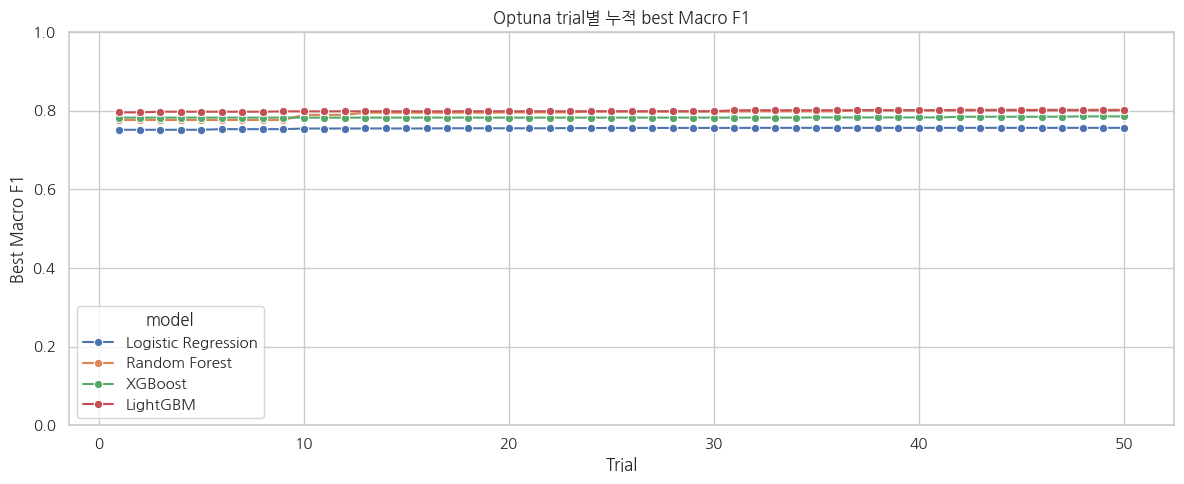

In [9]:
trial_rows = []
for model_name, study in studies.items():
    best_so_far = -np.inf
    for trial in study.trials:
        if trial.value is None:
            continue
        best_so_far = max(best_so_far, trial.value)
        trial_rows.append({
            'model': model_name,
            'trial': trial.number + 1,
            'macro_f1': trial.value,
            'best_so_far': best_so_far,
            'state': trial.state.name,
        })

trial_history_df = pd.DataFrame(trial_rows)
display(trial_history_df.tail(20))

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=trial_history_df, x='trial', y='best_so_far', hue='model', marker='o', ax=ax)
ax.set_title('Optuna trial별 누적 best Macro F1')
ax.set_xlabel('Trial')
ax.set_ylabel('Best Macro F1')
ax.set_ylim(0, 1)
plt.tight_layout()

## 튜닝 모델 검증 성능

In [10]:
# Optuna가 찾은 best params로 validation 평가용 모델을 다시 구성한다.
tuned_models = {
    'Logistic Regression': make_model_pipeline(
        LogisticRegression(
            **best_params['Logistic Regression'],
            solver='saga',
            max_iter=5000,
            random_state=SEED,
            n_jobs=-1,
        ),
        scale_numeric=True,
    ),
    'Random Forest': make_model_pipeline(
        RandomForestClassifier(**best_params['Random Forest'], random_state=SEED, n_jobs=-1),
        scale_numeric=False,
    ),
    'XGBoost': make_model_pipeline(
        xgb.XGBClassifier(
            **best_params['XGBoost'],
            random_state=SEED,
            seed=SEED,
            eval_metric='logloss',
            tree_method='hist',
            scale_pos_weight=scale_pos_weight,
            n_jobs=-1,
        ),
        scale_numeric=False,
    ),
    'LightGBM': make_model_pipeline(
        lgb.LGBMClassifier(**best_params['LightGBM'], random_state=SEED, verbose=-1, n_jobs=1),
        scale_numeric=False,
    ),
}

tuned_results = [evaluate_model(name, model) for name, model in tuned_models.items()]
tuned_summary_df = pd.DataFrame([
    {k: v for k, v in row.items() if k not in ['fitted_model', 'valid_proba']}
    for row in tuned_results
]).sort_values('macro_f1', ascending=False).reset_index(drop=True)
display(tuned_summary_df)

[Logistic Regression] 검증 성능
Accuracy : 0.9568
Macro F1 : 0.7848
ROC AUC  : 0.8729

분류 리포트
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5880
           1       0.71      0.51      0.59       386

    accuracy                           0.96      6266
   macro avg       0.84      0.75      0.78      6266
weighted avg       0.95      0.96      0.95      6266

Confusion matrix
[[5798   82]
 [ 189  197]]
[Random Forest] 검증 성능
Accuracy : 0.9603
Macro F1 : 0.7803
ROC AUC  : 0.8460

분류 리포트
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      5880
           1       0.83      0.45      0.58       386

    accuracy                           0.96      6266
   macro avg       0.90      0.72      0.78      6266
weighted avg       0.96      0.96      0.95      6266

Confusion matrix
[[5844   36]
 [ 213  173]]
[XGBoost] 검증 성능
Accuracy : 0.9560
Macro F1 : 0.7793
ROC AUC  : 0.8641

분류 리포트
      

,model,accuracy,macro_f1,roc_auc
0,Logistic Regression,0.956751,0.784822,0.872890
1,Random Forest,0.960262,0.780327,0.845968
2,XGBoost,0.955953,0.779285,0.864079
3,LightGBM,0.958506,0.778051,0.876231


,model,accuracy,macro_f1,roc_auc,stage
4,Logistic Regression,0.956751,0.784822,0.872890,tuned
0,LightGBM,0.957389,0.783064,0.875609,baseline
1,Random Forest,0.961060,0.783004,0.864699,baseline
2,XGBoost,0.958027,0.781208,0.862443,baseline
5,Random Forest,0.960262,0.780327,0.845968,tuned
6,XGBoost,0.955953,0.779285,0.864079,tuned
7,LightGBM,0.958506,0.778051,0.876231,tuned
3,Logistic Regression,0.892435,0.687564,0.880058,baseline


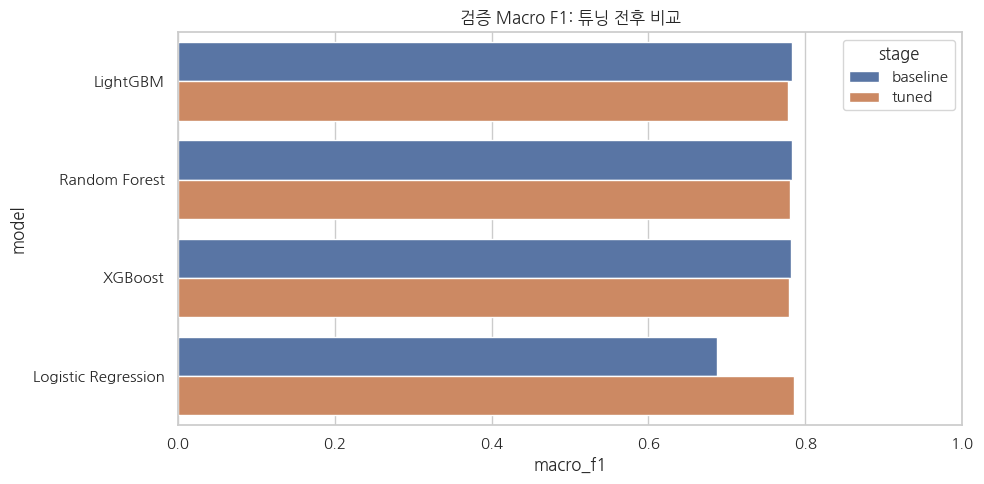

In [11]:
# 튜닝 전후 성능을 같은 validation 기준으로 비교한다.
comparison_df = pd.concat([summary_df.assign(stage='baseline'), tuned_summary_df.assign(stage='tuned')], ignore_index=True)
display(comparison_df.sort_values('macro_f1', ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=comparison_df, x='macro_f1', y='model', hue='stage', ax=ax)
ax.set_title('검증 Macro F1: 튜닝 전후 비교')
ax.set_xlim(0, 1)
plt.tight_layout()

## 튜닝 모델 Stacking 검증 성능

In [12]:
def stacking_predict(base_model_dict):
    # base model의 OOF 확률을 meta model 입력으로 사용한다.
    # CV는 train_inner 안에서만 수행한다. validation은 최종 선택용으로만 남겨둔다.
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    oof_preds = np.zeros((len(X_train), len(base_model_dict)))
    valid_preds = np.zeros((len(X_valid), len(base_model_dict)))
    fitted_base_models = {}
    X = X_train.reset_index(drop=True)
    y = y_train.reset_index(drop=True)

    for model_idx, (model_name, model) in enumerate(base_model_dict.items()):
        valid_fold_preds = np.zeros((len(X_valid), skf.n_splits))
        print(f'[{model_name}] CV 시작')
        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
            fold_model = clone(model)
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
            fold_model.fit(X_tr, y_tr)

            oof_preds[val_idx, model_idx] = fold_model.predict_proba(X_val)[:, 1]
            valid_fold_preds[:, fold - 1] = fold_model.predict_proba(X_valid)[:, 1]
            fold_pred = (oof_preds[val_idx, model_idx] >= 0.5).astype(int)
            print(f'  Fold {fold} macro F1: {f1_score(y_val, fold_pred, average="macro"):.4f}')

        valid_preds[:, model_idx] = valid_fold_preds.mean(axis=1)

        # 피처 중요도와 이후 해석을 위해 전체 train_inner로 최종 base model을 다시 학습한다.
        final_base = clone(model)
        final_base.fit(X_train, y_train)
        fitted_base_models[model_name] = final_base

    meta_model = LogisticRegression(penalty='l1', solver='saga', C=1.0, max_iter=3000, random_state=SEED)
    meta_model.fit(oof_preds, y_train)
    final_pred = meta_model.predict(valid_preds)
    final_proba = meta_model.predict_proba(valid_preds)[:, 1]

    evaluate_predictions('Stacking (LR+RF+XGB+LGBM)', y_valid, final_pred, final_proba)
    return meta_model, fitted_base_models, final_proba, final_pred

In [13]:
meta_model, fitted_base_models, stacking_valid_proba, stacking_valid_pred = stacking_predict(tuned_models)

[Logistic Regression] CV 시작
  Fold 1 macro F1: 0.7672
  Fold 2 macro F1: 0.7466
  Fold 3 macro F1: 0.7349
  Fold 4 macro F1: 0.7757
  Fold 5 macro F1: 0.7601
[Random Forest] CV 시작
  Fold 1 macro F1: 0.8006
  Fold 2 macro F1: 0.7950
  Fold 3 macro F1: 0.7986
  Fold 4 macro F1: 0.7954
  Fold 5 macro F1: 0.8250
[XGBoost] CV 시작
  Fold 1 macro F1: 0.7913
  Fold 2 macro F1: 0.7793
  Fold 3 macro F1: 0.7732
  Fold 4 macro F1: 0.7832
  Fold 5 macro F1: 0.8031
[LightGBM] CV 시작
  Fold 1 macro F1: 0.8040
  Fold 2 macro F1: 0.7998
  Fold 3 macro F1: 0.7925
  Fold 4 macro F1: 0.7948
  Fold 5 macro F1: 0.8172
[Stacking (LR+RF+XGB+LGBM)] 검증 성능
Accuracy : 0.9603
Macro F1 : 0.7929
ROC AUC  : 0.8663

분류 리포트
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5880
           1       0.78      0.50      0.61       386

    accuracy                           0.96      6266
   macro avg       0.87      0.74      0.79      6266
weighted avg       0.96      

## Stacking 성능 및 meta model 중요도

튜닝된 base model로 만든 stacking의 validation F1 score를 비교하고, meta model 계수로 base model 중요도를 확인한다.

,model,accuracy,macro_f1,roc_auc
0,Stacking (meta model),0.960262,0.792854,0.866263
1,LightGBM,0.957389,0.783064,0.875609
2,Random Forest,0.961060,0.783004,0.864699
3,XGBoost,0.958027,0.781208,0.862443
4,Logistic Regression,0.892435,0.687564,0.880058


,base_model,coefficient,importance
0,Random Forest,5.185963,5.185963
1,Logistic Regression,2.194766,2.194766
2,XGBoost,0.512915,0.512915
3,LightGBM,0.189324,0.189324


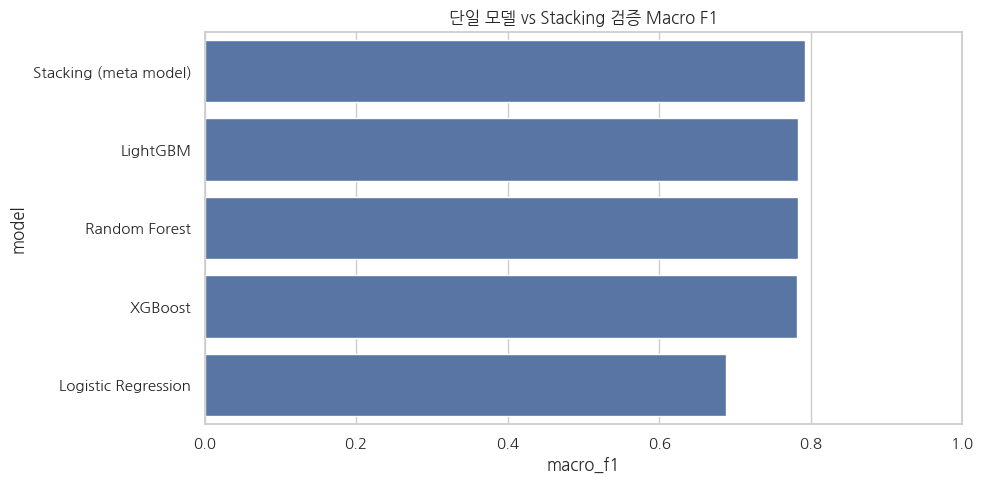

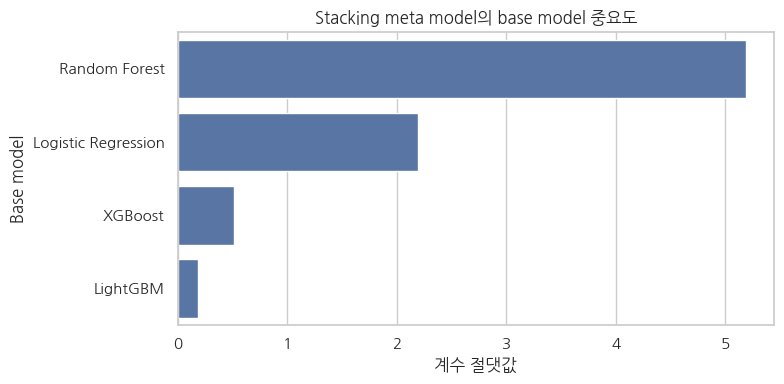

In [14]:
# 단일 모델들과 stacking meta model을 같은 validation 기준으로 비교한다.
stacking_metrics = {
    'model': 'Stacking (meta model)',
    'accuracy': accuracy_score(y_valid, stacking_valid_pred),
    'macro_f1': f1_score(y_valid, stacking_valid_pred, average='macro'),
    'roc_auc': roc_auc_score(y_valid, stacking_valid_proba),
}
model_selection_df = pd.concat([
    summary_df[['model', 'accuracy', 'macro_f1', 'roc_auc']],
    pd.DataFrame([stacking_metrics]),
], ignore_index=True).sort_values('macro_f1', ascending=False).reset_index(drop=True)
display(model_selection_df)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=model_selection_df, x='macro_f1', y='model', ax=ax)
ax.set_title('단일 모델 vs Stacking 검증 Macro F1')
ax.set_xlim(0, 1)
plt.tight_layout()

# meta model 계수 절댓값으로 base model별 중요도를 확인한다.
meta_importance_df = pd.DataFrame({
    'base_model': list(tuned_models.keys()),
    'coefficient': meta_model.coef_[0],
})
meta_importance_df['importance'] = meta_importance_df['coefficient'].abs()
meta_importance_df = meta_importance_df.sort_values('importance', ascending=False).reset_index(drop=True)
display(meta_importance_df)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=meta_importance_df, x='importance', y='base_model', ax=ax)
ax.set_title('Stacking meta model의 base model 중요도')
ax.set_xlabel('계수 절댓값')
ax.set_ylabel('Base model')
plt.tight_layout()

## Stacking 기준 Threshold 튜닝

In [15]:
# threshold는 선택된 stacking meta model의 validation 예측 확률을 기준으로 탐색한다.
threshold_df = find_best_threshold(y_valid, stacking_valid_proba)
display(threshold_df.head(10))

best_threshold = threshold_df.loc[0, 'threshold']
threshold_pred = (stacking_valid_proba >= best_threshold).astype(int)
evaluate_predictions(
    f'Stacking meta model threshold={best_threshold:.2f}',
    y_valid,
    threshold_pred,
    stacking_valid_proba,
)

,threshold,macro_f1
0,0.32,0.800070
1,0.31,0.798591
2,0.33,0.798474
3,0.34,0.797855
4,0.38,0.797594
5,0.39,0.797527
6,0.35,0.797226
7,0.30,0.797122
8,0.37,0.797090
9,0.24,0.797006


[Stacking meta model threshold=0.32] 검증 성능
Accuracy : 0.9585
Macro F1 : 0.8001
ROC AUC  : 0.8663

분류 리포트
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5880
           1       0.71      0.55      0.62       386

    accuracy                           0.96      6266
   macro avg       0.84      0.77      0.80      6266
weighted avg       0.95      0.96      0.96      6266

Confusion matrix
[[5792   88]
 [ 172  214]]


## Validation 기준 비용-편익 분석

튜닝된 Stacking meta model의 기본 threshold 0.50과 validation에서 튜닝한 threshold를 비교한다. 비용 계산은 validation 데이터만 사용하며, test 데이터는 사용하지 않는다.

In [16]:
# 비용-편익 분석은 validation 원본 데이터와 tuned stacking meta model 예측만 사용한다.
COST_FIXED_FP = 23.0
DEFAULT_THRESHOLD = 0.50


def recovery_cost_per_1000(delay_days):
    # FN은 실제 연체를 놓친 경우로 보고, 연체 기간별 회수 비용을 적용한다.
    if delay_days <= 30:
        return 1.5
    if delay_days <= 60:
        return 5.0
    if delay_days <= 90:
        return 8.0
    return 10.5


def make_validation_cost_frame(pred, pred_proba, scenario):
    # amount_in_usd는 로그 변환 값이므로 실제 금액으로 복원한다.
    frame = valid_raw.copy().reset_index(drop=True)
    frame['y_true'] = y_valid.reset_index(drop=True).values
    frame['y_pred'] = np.asarray(pred).astype(int)
    frame['pred_proba'] = np.asarray(pred_proba)
    frame['scenario'] = scenario
    frame['delay_days'] = frame['business_days_late'].clip(lower=0)
    frame['amount_usd_actual'] = np.expm1(frame['amount_in_usd'])

    frame['is_fn'] = (frame['y_true'] == 1) & (frame['y_pred'] == 0)
    frame['is_fp'] = (frame['y_true'] == 0) & (frame['y_pred'] == 1)
    frame['is_tp'] = (frame['y_true'] == 1) & (frame['y_pred'] == 1)
    frame['is_tn'] = (frame['y_true'] == 0) & (frame['y_pred'] == 0)

    frame['cost_per_1000'] = frame['delay_days'].apply(recovery_cost_per_1000)
    frame['fn_recovery_cost'] = np.where(
        frame['is_fn'],
        frame['amount_usd_actual'] / 1000 * frame['cost_per_1000'],
        0.0,
    )
    frame['fp_fixed_cost'] = np.where(frame['is_fp'], COST_FIXED_FP, 0.0)
    frame['total_error_cost'] = frame['fn_recovery_cost'] + frame['fp_fixed_cost']
    return frame


def summarize_cost(frame):
    return {
        'scenario': frame['scenario'].iloc[0],
        'threshold': frame.attrs.get('threshold'),
        'tp': int(frame['is_tp'].sum()),
        'tn': int(frame['is_tn'].sum()),
        'fp': int(frame['is_fp'].sum()),
        'fn': int(frame['is_fn'].sum()),
        'fn_recovery_cost': frame['fn_recovery_cost'].sum(),
        'fp_fixed_cost': frame['fp_fixed_cost'].sum(),
        'total_error_cost': frame['total_error_cost'].sum(),
        'macro_f1': f1_score(frame['y_true'], frame['y_pred'], average='macro'),
        'accuracy': accuracy_score(frame['y_true'], frame['y_pred']),
    }


stacking_default_pred = (stacking_valid_proba >= DEFAULT_THRESHOLD).astype(int)
stacking_tuned_pred = threshold_pred

default_cost_df = make_validation_cost_frame(
    stacking_default_pred,
    stacking_valid_proba,
    f'Stacking threshold={DEFAULT_THRESHOLD:.2f}',
)
default_cost_df.attrs['threshold'] = DEFAULT_THRESHOLD

tuned_cost_df = make_validation_cost_frame(
    stacking_tuned_pred,
    stacking_valid_proba,
    f'Stacking threshold={best_threshold:.2f}',
)
tuned_cost_df.attrs['threshold'] = best_threshold

cost_summary_df = pd.DataFrame([
    summarize_cost(default_cost_df),
    summarize_cost(tuned_cost_df),
])
base_total_cost = cost_summary_df.loc[0, 'total_error_cost']
cost_summary_df['cost_saving_vs_default'] = base_total_cost - cost_summary_df['total_error_cost']
cost_summary_df['cost_saving_rate'] = np.where(
    base_total_cost > 0,
    cost_summary_df['cost_saving_vs_default'] / base_total_cost,
    0.0,
)

cost_display_cols = [
    'scenario', 'threshold', 'accuracy', 'macro_f1', 'tp', 'tn', 'fp', 'fn',
    'fn_recovery_cost', 'fp_fixed_cost', 'total_error_cost',
    'cost_saving_vs_default', 'cost_saving_rate',
]
display(cost_summary_df[cost_display_cols])

,scenario,threshold,accuracy,macro_f1,tp,tn,fp,fn,fn_recovery_cost,fp_fixed_cost,total_error_cost,cost_saving_vs_default,cost_saving_rate
0,Stacking threshold=0.50,0.50,0.960262,0.792854,192,5825,55,194,9987.556280,1265.0,11252.556280,0.000000,0.000000
1,Stacking threshold=0.32,0.32,0.958506,0.800070,214,5792,88,172,8742.914681,2024.0,10766.914681,485.641599,0.043158


튜닝 threshold 적용 후 비용 절감액: $486
튜닝 threshold 적용 후 비용 절감률: 4.32%


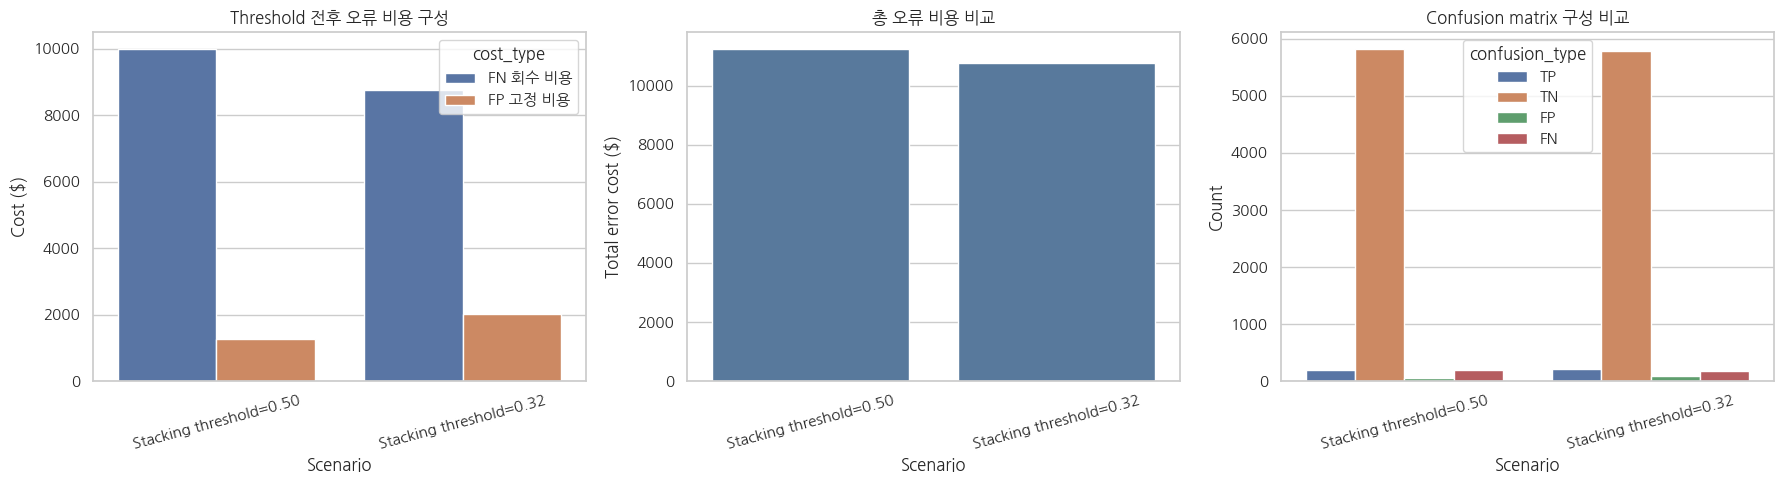

In [17]:
# threshold 튜닝 전후의 오류 비용과 confusion matrix 구성을 함께 시각화한다.
plot_df = cost_summary_df.melt(
    id_vars='scenario',
    value_vars=['fn_recovery_cost', 'fp_fixed_cost'],
    var_name='cost_type',
    value_name='cost',
)
plot_df['cost_type'] = plot_df['cost_type'].map({
    'fn_recovery_cost': 'FN 회수 비용',
    'fp_fixed_cost': 'FP 고정 비용',
})

confusion_plot_df = cost_summary_df.melt(
    id_vars='scenario',
    value_vars=['tp', 'tn', 'fp', 'fn'],
    var_name='confusion_type',
    value_name='count',
)
confusion_plot_df['confusion_type'] = confusion_plot_df['confusion_type'].str.upper()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=plot_df, x='scenario', y='cost', hue='cost_type', ax=axes[0])
axes[0].set_title('Threshold 전후 오류 비용 구성')
axes[0].set_xlabel('Scenario')
axes[0].set_ylabel('Cost ($)')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=cost_summary_df, x='scenario', y='total_error_cost', ax=axes[1], color='#4C78A8')
axes[1].set_title('총 오류 비용 비교')
axes[1].set_xlabel('Scenario')
axes[1].set_ylabel('Total error cost ($)')
axes[1].tick_params(axis='x', rotation=15)

sns.barplot(data=confusion_plot_df, x='scenario', y='count', hue='confusion_type', ax=axes[2])
axes[2].set_title('Confusion matrix 구성 비교')
axes[2].set_xlabel('Scenario')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()

print(f"튜닝 threshold 적용 후 비용 절감액: ${cost_summary_df.loc[1, 'cost_saving_vs_default']:,.0f}")
print(f"튜닝 threshold 적용 후 비용 절감률: {cost_summary_df.loc[1, 'cost_saving_rate']:.2%}")

## 최종 Stacking 모델 저장

Validation에서 선택한 tuned stacking 구조와 threshold 0.32를 고정하고, test 평가 전에 train 전체 데이터로 최종 모델을 다시 학습해 저장한다. test 데이터는 여기서 사용하지 않는다.

In [18]:
# 05_test_cost_analysis.ipynb에서 재사용할 최종 artifact를 저장한다.
# validation으로 선택한 threshold는 고정하고, 최종 모델은 train 전체 데이터로 다시 학습한다.
import joblib

PROJECT_ROOT = next(
    candidate for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / 'data' / 'train_eda_fixed.csv').exists()
)
MODEL_DIR = PROJECT_ROOT / 'models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_PATH = MODEL_DIR / 'stacking_tuned_threshold_032.joblib'
FINAL_THRESHOLD = 0.32

X_full, y_full = split_xy(raw)


def fit_final_stacking(base_model_dict, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)
    oof_preds = np.zeros((len(X), len(base_model_dict)))
    fitted_base_models = {}

    for model_idx, (model_name, model) in enumerate(base_model_dict.items()):
        print(f'[{model_name}] final OOF 학습 시작')
        for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), start=1):
            fold_model = clone(model)
            fold_model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
            oof_preds[val_idx, model_idx] = fold_model.predict_proba(X.iloc[val_idx])[:, 1]
            fold_pred = (oof_preds[val_idx, model_idx] >= 0.5).astype(int)
            print(f'  Fold {fold} macro F1: {f1_score(y.iloc[val_idx], fold_pred, average="macro"):.4f}')

        final_base = clone(model)
        final_base.fit(X, y)
        fitted_base_models[model_name] = final_base

    final_meta_model = LogisticRegression(
        penalty='l1',
        solver='saga',
        C=1.0,
        max_iter=3000,
        random_state=SEED,
    )
    final_meta_model.fit(oof_preds, y)
    return final_meta_model, fitted_base_models, oof_preds


final_meta_model, final_base_models, final_oof_preds = fit_final_stacking(tuned_models, X_full, y_full)
final_oof_proba = final_meta_model.predict_proba(final_oof_preds)[:, 1]
final_oof_pred = (final_oof_proba >= FINAL_THRESHOLD).astype(int)

evaluate_predictions(
    f'Final train-full stacking threshold={FINAL_THRESHOLD:.2f} OOF',
    y_full,
    final_oof_pred,
    final_oof_proba,
)

model_artifact = {
    'model_name': 'tuned_stacking_threshold_032',
    'base_model_order': list(tuned_models.keys()),
    'base_models': final_base_models,
    'meta_model': final_meta_model,
    'threshold': FINAL_THRESHOLD,
    'drop_cols': DROP_COLS,
    'target_col': TARGET_COL,
    'date_col': DATE_COL,
    'feature_columns': X_full.columns.tolist(),
    'categorical_columns': cat_cols,
    'numeric_columns': num_cols,
    'best_params': best_params,
    'cost_config': {
        'fixed_fp_cost': COST_FIXED_FP,
        'recovery_cost_per_1000': {
            '<=30': 1.5,
            '<=60': 5.0,
            '<=90': 8.0,
            '>90': 10.5,
        },
    },
    'validation_cost_summary': cost_summary_df[cost_display_cols].copy(),
}

joblib.dump(model_artifact, ARTIFACT_PATH)
print(f'저장 완료: {ARTIFACT_PATH}')

[Logistic Regression] final OOF 학습 시작
  Fold 1 macro F1: 0.7470
  Fold 2 macro F1: 0.7605
  Fold 3 macro F1: 0.7690
  Fold 4 macro F1: 0.7700
  Fold 5 macro F1: 0.7482
[Random Forest] final OOF 학습 시작
  Fold 1 macro F1: 0.8019
  Fold 2 macro F1: 0.8165
  Fold 3 macro F1: 0.8082
  Fold 4 macro F1: 0.7997
  Fold 5 macro F1: 0.8081
[XGBoost] final OOF 학습 시작
  Fold 1 macro F1: 0.7927
  Fold 2 macro F1: 0.8000
  Fold 3 macro F1: 0.7828
  Fold 4 macro F1: 0.7722
  Fold 5 macro F1: 0.7910
[LightGBM] final OOF 학습 시작
  Fold 1 macro F1: 0.7964
  Fold 2 macro F1: 0.8077
  Fold 3 macro F1: 0.8082
  Fold 4 macro F1: 0.7991
  Fold 5 macro F1: 0.7982
[Final train-full stacking threshold=0.32 OOF] 검증 성능
Accuracy : 0.9599
Macro F1 : 0.8156
ROC AUC  : 0.9070

분류 리포트
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     29242
           1       0.77      0.57      0.65      2084

    accuracy                           0.96     31326
   macro avg       0.87 